# PROJETO DE PARCERIA -- SEMANTIX -- CIÊNCIA DE DADOS

## Predição da propensão de compra de automóveis

### Problemática

Uma empresa do setor automotivo possui informações básicas sobre seus clientes e deseja utilizar dados para identificar quais pessoas apresentam maior propensão a comprar um automóvel.


## Objetivos do projeto


1. Exploração e limpeza dos dados.
2. Análise exploratória e storytelling.
3. Identificação das variáveis mais relevantes.
4. Codificação da variável categórica.
5. Separação entre variáveis independentes e dependente.
6. Divisão em treino e teste.
7. Treinamento e avaliação de modelos.
8. Comparação entre dois modelos.
9. Visualização dos resultados.
10. Conclusão e recomendações para a problemática.

In [9]:
# Importação dos dados.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pip._internal.commands import download

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

### Justificativa da escolha das bibliotecas.


- **pandas** e **numpy** : tratamento e análise dos dados;
- **matplotlib** e **seaborn**: visualização;
- **LabelEncoder**: transformação da variável categórica;
- **StandardScaler**: padronização das variáveis numéricas;
- **train_test_split**: divisão entre treino e teste;
- **GridSearchCV** e **StratifiedKFold**: otimização e validação cruzada;
- **DecisionTreeClassifier** e **XGBClassifier**: os dois modelos do duelo;
- métricas do **sklearn**: avaliação dos resultados.

# Gráficos.

Gráficos não apresentados na aula, porém buscados no site.  https://seaborn.pydata.org/tutorial/distributions.html.

### Carrgando a base de dados.

In [10]:
# FONTE DA BASE.
# Base de dados fornecida pelo Instituto EBAC(Escola Britânica de Artes Criativas e Tecnologia)
df = pd.read_csv('CARRO_CLIENTES.csv')


In [11]:
# Carregando informações.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


A base possui 1.000 registros e cinco colunas: identificador, gênero, idade, renda anual e decisão de compra.

O objetivo do projeto não é prever o identificador. O **User ID** será removido porque representa apenas a identificação do cliente e não uma característica comportamental ou financeira útil para a previsão.

### Exploração e limpeza de dados.

In [12]:
print("Tipos das colunas:")
display(df.dtypes)

print("\nValores ausentes:")
display(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nEstatísticas descritivas:")
display(df.describe())

Tipos das colunas:


User ID         int64
Gender            str
Age             int64
AnnualSalary    int64
Purchased       int64
dtype: object


Valores ausentes:


User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64


Duplicados:
0

Estatísticas descritivas:


,User ID,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.106000,72689.000000,0.402000
std,288.819436,10.707073,34488.341867,0.490547
min,1.000000,18.000000,15000.000000,0.000000
25%,250.750000,32.000000,46375.000000,0.000000
50%,500.500000,40.000000,72000.000000,0.000000
75%,750.250000,48.000000,90000.000000,1.000000
max,1000.000000,63.000000,152500.000000,1.000000


### Insight da limpeza

A verificação permite confirmar se existem problemas que possam comprometer a modelagem.

Nesta base foram encontrados:

- **nenhum valor ausente**;
- **nenhuma linha duplicada**;
- `Gender` como variável categórica;
- `Age`, `AnnualSalary`, `User ID` e `Purchased` como variáveis numéricas

In [13]:
# Removendo a coluna User ID como havia dito.
df = df.drop(columns=["User ID"])

display(df.head())

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0



### Justificativa

`User ID` é apenas um identificador. Utilizá-lo como variável preditora poderia fazer o modelo encontrar padrões relacionados ao número do registro, sem significado para a decisão de compra.

Por isso, a coluna é removida antes da modelagem.

In [14]:
encoder = LabelEncoder()

df["GenderEncoded"] = encoder.fit_transform(df["Gender"])

print("Mapeamento utilizado:")
for categoria, valor in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{categoria} -> {valor}")

df = df.drop(columns=["Gender"])


Mapeamento utilizado:
Female -> 0
Male -> 1


## Justificativa
Os algoritmos de Machine Learning utilizados precisam receber as variáveis em formato numérico.

O LabelEncoder transforma as duas categorias de Gender em números e a coluna original é removida, mantendo somente GenderEncoded.

O código imprime o mapeamento para que a transformação fique documentada e reproduzível.

# Análise exploratória — distribuição do alvo

Quantidade por classe:


Purchased
0    598
1    402
Name: count, dtype: int64

Percentual por classe:


Purchased
0    59.8
1    40.2
Name: proportion, dtype: float64

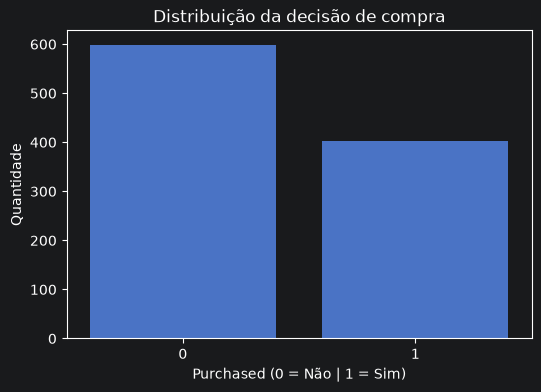

In [15]:
contagem = df["Purchased"].value_counts().sort_index()
percentual = df["Purchased"].value_counts(normalize=True).sort_index() * 100

print("Quantidade por classe:")
display(contagem)

print("Percentual por classe:")
display(percentual.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Purchased")
plt.title("Distribuição da decisão de compra")
plt.xlabel("Purchased (0 = Não | 1 = Sim)")
plt.ylabel("Quantidade")
plt.show()

### Insight
A classe 0 representa 598 clientes e a classe 1 representa 402.

Existe, portanto, um desbalanceamento moderado entre as classes. Como a diferença não é extrema, nesta primeira solução optamos por manter a distribuição original e usar stratify=y na divisão dos dados.

A avaliação não ficará restrita à acurácia: precisão, recall e F1-score também serão observados.

# Análise por Idade

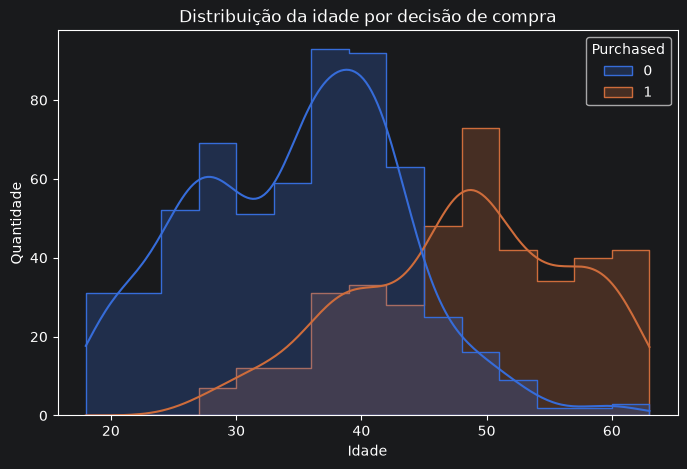

,mean,median,min,max
Purchased,,,,
0,34.70,36.0,18,62
1,48.15,49.0,27,63


In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Purchased", bins=15, kde=True, element="step")
plt.title("Distribuição da idade por decisão de compra")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

display(
    df.groupby("Purchased")["Age"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)

### Insight

A idade apresenta uma diferença importante entre os grupos.

Na base analisada, os clientes que compraram apresentam idade média maior que os clientes que não compraram. Isso indica que `Age` pode ser uma variável relevante para a previsão.

# Análise de Renda Anual.

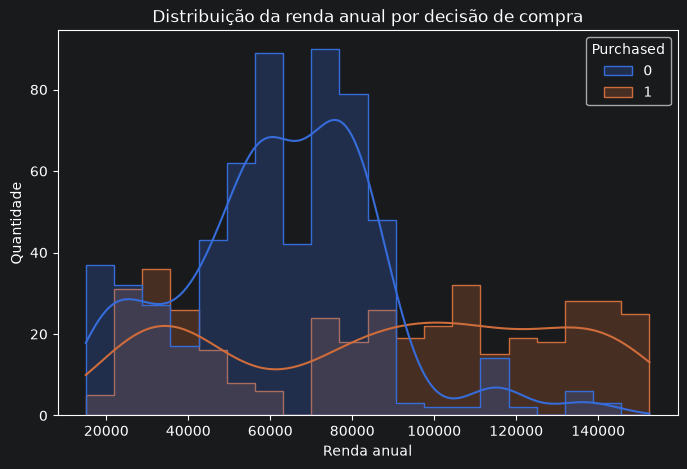

,mean,median,min,max
Purchased,,,,
0,62373.75,62500.0,15000,143500
1,88033.58,92000.0,20000,152500


In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="AnnualSalary", hue="Purchased", bins=20, kde=True, element="step")
plt.title("Distribuição da renda anual por decisão de compra")
plt.xlabel("Renda anual")
plt.ylabel("Quantidade")
plt.show()

display(
    df.groupby("Purchased")["AnnualSalary"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)


### Insight

A renda anual também apresenta diferenças entre os grupos de compra.

Em média, clientes que compraram possuem renda anual maior. Portanto, **AnnualSalary** também aparece como uma variável potencialmente relevante para o problema.

# Análise por gênero

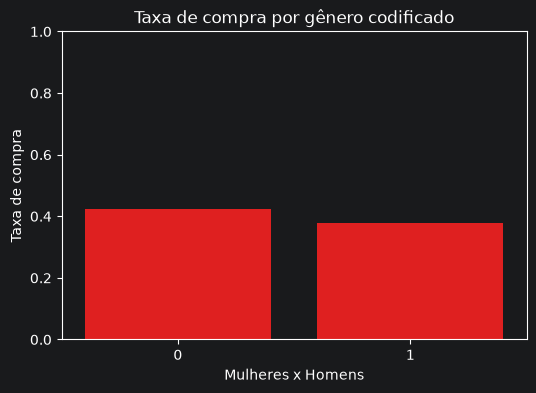

,GenderEncoded,Purchased
0,0,0.424419
1,1,0.378099


In [18]:
taxa_genero = (
    df.groupby("GenderEncoded")["Purchased"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=taxa_genero, x="GenderEncoded", y="Purchased", color='Red')
plt.title("Taxa de compra por gênero codificado")
plt.xlabel("Mulheres x Homens")
plt.ylabel("Taxa de compra")
plt.ylim(0, 1)
plt.show()

display(taxa_genero)

### Insight

A variável de gênero apresenta diferença menor que idade e renda na análise exploratória.

Isso não significa que ela seja inútil automaticamente. Uma variável pode contribuir para o modelo em conjunto com outras, mesmo que sua relação isolada seja pequena.

Essa hipótese será verificada novamente na correlação e nas métricas de importância dos modelos.

# Relação entre Idade, renda anual e compra

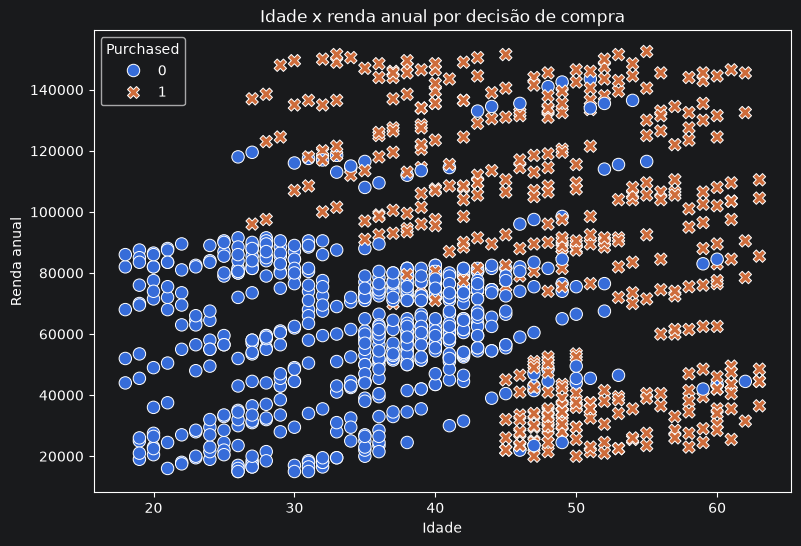

In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="AnnualSalary",
    hue="Purchased",
    style="Purchased",
    s=80
)
plt.title("Idade x renda anual por decisão de compra")
plt.xlabel("Idade")
plt.ylabel("Renda anual")
plt.show()

### Insight

O gráfico evidencia que idade e renda, combinadas, ajudam a separar grupos com maior e menor ocorrência de compra.

Esse comportamento sugere que um modelo capaz de identificar relações não lineares pode ser útil para o problema. Por isso, Árvore de Decisão e XGBoost são escolhas adequadas.

# Matriz de correlação

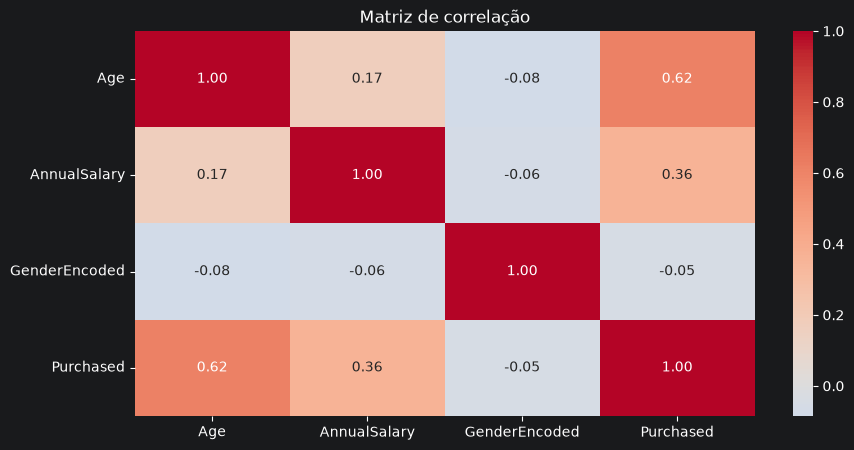

Correlação com Purchased:


Age              0.616036
AnnualSalary     0.364974
GenderEncoded   -0.047211
Purchased        1.000000
Name: Purchased, dtype: float64

In [20]:
correlacao = df[
    ["Age", "AnnualSalary", "GenderEncoded", "Purchased"]
].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação")
plt.show()

print("Correlação com Purchased:")
display(
    correlacao["Purchased"]
)

### Insight da correlação

As maiores correlações com **Purchased** são:

- `Age` ≈ **0,62**
- `AnnualSalary` ≈ **0,36**
- `GenderEncoded` ≈ **-0,05**

A idade apresenta a relação linear mais forte com o alvo, seguida pela renda anual.

**GenderEncoded** apresenta correlação próxima de zero, indicando uma relação linear muito fraca com a compra.

Mesmo assim, não vamos remover **GenderEncoded** neste momento, porque correlação mede apenas uma relação específica e não captura todas as interações e relações não lineares que podem ser aprendidas pelos modelos.

# Separação e Divisão de treino e teste


In [21]:
X = df.drop(columns=["Purchased"])
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [22]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 3)
X_test : (200, 3)
y_train: (800,)
y_test : (200,)


# Insight

Essa separação é necessária para ensinar o modelo quais informações usar para prever a variável de interesse.
Foi utilizada a proporção de 80% para treino e 20% para teste.

# Padronizando os dados.

In [23]:
scaler = StandardScaler()

X_train_padronizado = X_train.copy()
X_test_padronizado = X_test.copy()

colunas_para_padronizar = ["Age", "AnnualSalary"]

X_train_padronizado[colunas_para_padronizar] = scaler.fit_transform(
    X_train_padronizado[colunas_para_padronizar]
)

X_test_padronizado[colunas_para_padronizar] = scaler.transform(
    X_test_padronizado[colunas_para_padronizar]
)

display(X_train_padronizado.head())

,Age,AnnualSalary,GenderEncoded
739,-1.579058,-1.524551,1
112,-0.837716,-0.423897,1
334,1.756980,0.691240,0
19,-0.096374,1.777412,0
12,-0.745049,-0.003910,0


### Justificativa

A padronização coloca as variáveis numéricas em uma escala comparável.

Importante: o **scaler** é ajustado apenas com **X_train** e depois aplicado em **X_test**. Isso evita que informações do conjunto de teste influenciem o treinamento.

Neste projeto, Árvore de Decisão e XGBoost não dependem da escala das variáveis para funcionar. A padronização é apresentada como uma etapa aprendida no curso, mas não é o fator que determina o desempenho desses dois modelos.

# Árvore de Decisão

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parametros_arvore = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_arvore = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parametros_arvore,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_arvore.fit(X_train_padronizado, y_train)

print("Melhores parâmetros da Árvore:")
print(grid_arvore.best_params_)

print("Melhor média na validação cruzada:")
print(round(grid_arvore.best_score_, 4))

Melhores parâmetros da Árvore:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Melhor média na validação cruzada:
0.9025


### Justificativa

Na Árvore de Decisão foram ajustados:

- **max_depth**: limita a profundidade da árvore e ajuda a controlar complexidade;
- **min_samples_split**: define o mínimo de amostras necessário para dividir um nó;
- **min_samples_leaf**: define o mínimo de amostras que uma folha pode ter.

O **GridSearchCV** testa combinações desses parâmetros usando 5 folds estratificados.

# 2º Modelo - XGBoost

In [25]:
parametros_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8, 1.0]
}

modelo_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=parametros_xgb,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train_padronizado, y_train)

print("Melhores parâmetros do XGBoost:")
print(grid_xgb.best_params_)

print("Melhor média na validação cruzada:")
print(round(grid_xgb.best_score_, 4))

Melhores parâmetros do XGBoost:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Melhor média na validação cruzada:
0.9125


### Justificativa

No XGBoost foram ajustados:

- **n_estimators**: quantidade de árvores;
- **max_depth**: profundidade das árvores;
- **learning_rate**: velocidade de aprendizagem;
- **subsample**: proporção dos dados utilizada em cada etapa.

A busca de **hiperparâmetros** permite evitar a escolha arbitrária dos parâmetros.

# Comparando os Modelos.


In [26]:
modelos = {
    "Árvore de Decisão": grid_arvore.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

resultados = []

for nome, modelo in modelos.items():
    previsoes = modelo.predict(X_test_padronizado)
    probabilidades = modelo.predict_proba(X_test_padronizado)[:, 1]

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, previsoes),
        "Precisão": precision_score(y_test, previsoes),
        "Recall": recall_score(y_test, previsoes),
        "F1-score": f1_score(y_test, previsoes),
        "ROC AUC": roc_auc_score(y_test, probabilidades)
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df.round(4))

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC AUC
0,Árvore de Decisão,0.915,0.9315,0.8500,0.8889,0.9712
1,XGBoost,0.910,0.8875,0.8875,0.8875,0.9749


### Insight

`Obs: Nessa executação dos resultados eu dei uma pesquisada sobre, como eu poderia trazer todos modelo de uma outra forma. Bom, eu gostei basntante.`

Inclusive ate esse modelo de deixar as fontes.


A comparação deve considerar o conjunto das métricas, não somente a acurácia.

No experimento realizado com **random_state=42**, a Árvore de Decisão apresentou desempenho ligeiramente superior na acurácia e precisão, enquanto o XGBoost apresentou maior recall e ROC AUC.

Isso mostra que o "melhor" modelo depende também do objetivo da empresa. Se o foco for identificar o maior número possível de potenciais compradores, o recall pode ter peso maior. Se o objetivo for reduzir abordagens desnecessárias, a precisão pode ser mais importante.

# Matrizes de Confusão

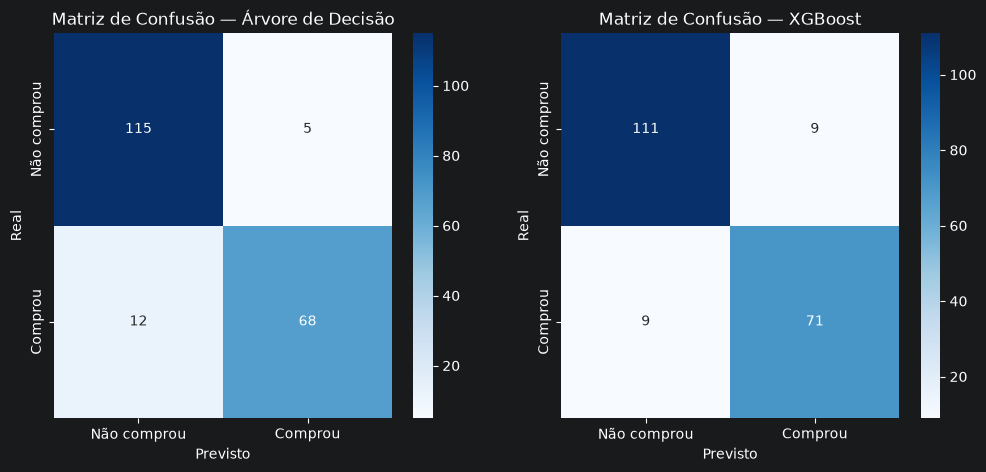

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    previsoes = modelo.predict(X_test_padronizado)
    cm = confusion_matrix(y_test, previsoes)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Não comprou", "Comprou"],
        yticklabels=["Não comprou", "Comprou"],
        ax=ax
    )

    ax.set_title(f"Matriz de Confusão — {nome}")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.show()

### Insight — matriz de confusão
A matriz de confusão mostra quantos clientes foram classificados corretamente ou incorretamente.

Para uma aplicação comercial, os dois principais tipos de erro possuem interpretações diferentes:

Falso positivo: o modelo indica propensão de compra, mas o cliente não compra. Pode gerar gasto desnecessário de marketing.
Falso negativo: o modelo indica que o cliente não compraria, mas ele compra. Pode fazer a empresa perder uma oportunidade comercial.
Por isso, a escolha do modelo deve considerar o custo desses dois erros.

# Feature Importances

Importância — Árvore de Decisão:


Age              0.5232
AnnualSalary     0.4689
GenderEncoded    0.0079
dtype: float64


Importância — XGBoost:


Age              0.5937
AnnualSalary     0.3268
GenderEncoded    0.0796
dtype: float32

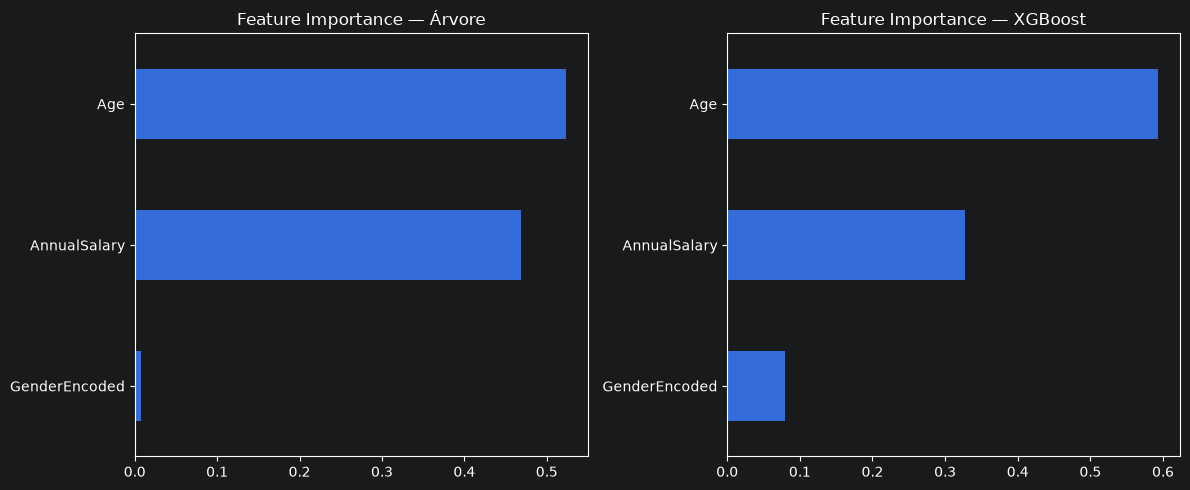

In [31]:
arvore_final = grid_arvore.best_estimator_
xgb_final = grid_xgb.best_estimator_

importancias_arvore = pd.Series(
    arvore_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias_xgb = pd.Series(
    xgb_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Importância — Árvore de Decisão:")
display(importancias_arvore.round(4))

print("\nImportância — XGBoost:")
display(importancias_xgb.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

importancias_arvore.sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Feature Importance — Árvore")

importancias_xgb.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Feature Importance — XGBoost")

plt.tight_layout()
plt.show()

### Insigths

Esse modelo de plotar foi umn desafio, confesso. mas enfim....

Os dois modelos tendem a considerar **Age** e **AnnualSalary** como as variáveis mais relevantes, enquanto **GenderEncoded** apresenta participação menor.

Esse resultado é coerente com a análise exploratória e com a matriz de correlação, na qual **Age** e **AnnualSalary** também apresentaram as maiores relações com **Purchased**.

A importância de variável, entretanto, não é a mesma coisa que correlação. A correlação mede uma associação, enquanto a importância do modelo representa o quanto cada variável contribui para as decisões realizadas pelas árvores.

# Comparação final: correlação × importância

In [32]:
comparacao_importancia = pd.DataFrame({
    "Correlacao_com_Purchased": correlacao["Purchased"].drop("Purchased"),
    "Importancia_Arvore": importancias_arvore,
    "Importancia_XGBoost": importancias_xgb
})

display(comparacao_importancia.sort_values(
    "Correlacao_com_Purchased",
    key=abs,
    ascending=False
).round(4))

,Correlacao_com_Purchased,Importancia_Arvore,Importancia_XGBoost
Age,0.6160,0.5232,0.5937
AnnualSalary,0.3650,0.4689,0.3268
GenderEncoded,-0.0472,0.0079,0.0796


### Conclusão

As variáveis mais relevantes pela correlação e pelos modelos são, em grande parte, as mesmas: **idade e renda anual**.

A `GenderEncoded` aparece com correlação muito baixa e também com menor importância nos modelos.

Os resultados coincidem parcialmente porque idade e renda realmente apresentam forte relação com a decisão de compra nessa base. Ainda assim, não se deve interpretar correlação como prova de causa, nem esperar que os rankings sejam idênticos: modelos baseados em árvores conseguem capturar limites, relações não lineares e interações entre variáveis.

# Visualização final

,Age,AnnualSalary,Probabilidade_XGBoost,Faixa_Probabilidade,Real
29,38,147500,0.995297,Muito alta,1
347,63,104500,0.994682,Muito alta,1
95,33,151500,0.993309,Muito alta,1
59,35,147000,0.993309,Muito alta,1
760,38,145500,0.992977,Muito alta,1
795,52,30500,0.988897,Muito alta,1
969,29,148000,0.983357,Muito alta,1
711,51,32500,0.983230,Muito alta,1
842,61,146500,0.982280,Muito alta,1
305,49,28000,0.979020,Muito alta,1


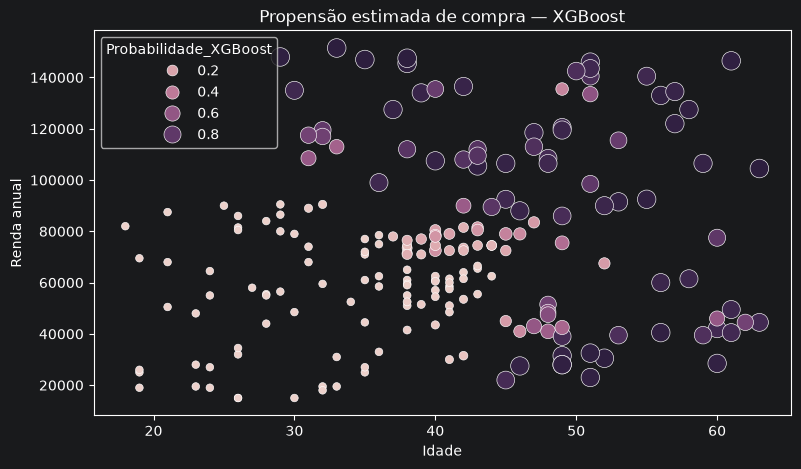

In [34]:
resultado_visual = X_test.copy()
resultado_visual["Real"] = y_test.values
resultado_visual["Previsto_XGBoost"] = grid_xgb.best_estimator_.predict(X_test_padronizado)
resultado_visual["Probabilidade_XGBoost"] = grid_xgb.best_estimator_.predict_proba(
    X_test_padronizado
)[:, 1]

resultado_visual["Faixa_Probabilidade"] = pd.cut(
    resultado_visual["Probabilidade_XGBoost"],
    bins=[0, 0.25, 0.50, 0.75, 1],
    labels=["Baixa", "Moderada", "Alta", "Muito alta"],
    include_lowest=True
)

display(
    resultado_visual[
        ["Age", "AnnualSalary", "Probabilidade_XGBoost", "Faixa_Probabilidade", "Real"]
    ].sort_values("Probabilidade_XGBoost", ascending=False).head(15)
)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=resultado_visual,
    x="Age",
    y="AnnualSalary",
    hue="Probabilidade_XGBoost",
    size="Probabilidade_XGBoost",
    sizes=(30, 180)
)
plt.title("Propensão estimada de compra — XGBoost")
plt.xlabel("Idade")
plt.ylabel("Renda anual")
plt.show()

### Insight

A probabilidade gerada pelo modelo pode ser utilizada como um **indicador de prioridade comercial**.

Por exemplo, clientes classificados em faixas de probabilidade mais altas poderiam receber uma abordagem comercial prioritária, enquanto clientes em faixas menores poderiam receber ações de relacionamento ou campanhas diferentes.

Esse uso deve ser tratado como apoio à decisão, e não como uma garantia de compra.

### Conclusão final.
O projeto mostrou que dados de idade, gênero e renda anual podem ser utilizados para desenvolver um modelo capaz de estimar a propensão de compra de automóveis.

A análise exploratória indicou que **idade e renda anual** são as variáveis mais relacionadas ao comportamento de compra nessa base.

Foram treinados dois modelos — **Árvore de Decisão e XGBoost** — utilizando busca de hiperparâmetros e validação cruzada. Os modelos foram avaliados por acurácia, precisão, recall, F1-score, ROC AUC e matriz de confusão.

O resultado demonstra como uma empresa poderia transformar dados históricos em uma ferramenta de apoio às estratégias de marketing e vendas, priorizando clientes com maior propensão e direcionando diferentes ações para públicos distintos.